# 04 -- Precalculus review: sinusoids, exponentials, logarithms

| question | answer |
|---|---|
| What physics problem? | Oscillation and decay are the two universal time behaviours. |
| What mathematics? | Trigonometric identities, the exponential, the logarithm. |
| What algorithm? | Rewrite a phase-shifted sinusoid as a sum of sine and cosine (phasor coefficients). |
| What software? | SymPy for identities; NumPy for sampled waveforms. |
| What experiment? | A signal generator emits a sinusoid; a decade counter spans logarithmic frequency. |
| What engineering application? | A direct-digital synthesizer generates a sinusoid from a phase accumulator. |

This notebook follows the repository template: English explanation, mathematical derivation,
dimensions and SI units, SymPy derivation, NumPy implementation, Pandas tables, Matplotlib plots,
optional PyTorch, exercises, and engineering applications. It reuses the `physkit` package and the
results of earlier chapters.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## English explanation

Two functions describe almost all elementary physics in time: the **sinusoid**, for anything
that oscillates, and the **exponential**, for anything that grows or decays. Their inverse, the
**logarithm**, turns multiplicative spans (decades of frequency, orders of magnitude of intensity)
into additive ones, which is why spectra and gains are plotted in decibels and log scales. This
chapter fixes the identities the calculus and Fourier chapters will lean on.

Subject-verb-object: the oscillator repeats; the exponential decays; the logarithm linearizes.

## Mathematical derivation

The angle-addition identity $\cos(\omega t+\phi)=\cos\phi\cos\omega t-\sin\phi\sin\omega t$
shows any phase-shifted sinusoid is a linear combination
$A\cos(\omega t+\phi)=a\cos\omega t+b\sin\omega t$ with $a=A\cos\phi$, $b=-A\sin\phi$; the pair
$(a,b)$ is the phasor of chapter 03. The exponential obeys $e^{x+y}=e^x e^y$ and
$\frac{d}{dx}e^{x}=e^{x}$; the logarithm inverts it, $\ln(xy)=\ln x+\ln y$.

## Dimensions and SI units

The argument of any sinusoid, exponential, or logarithm must be **dimensionless**. In
$\cos(\omega t)$, the angular frequency $\omega$ has units $\mathrm{rad/s}$ so that $\omega t$ is a
pure number; in $e^{-t/\tau}$, the time constant $\tau$ carries seconds. `physkit.units` confirms
$\omega t$ is dimensionless.

In [2]:
omega = U.Quantity(2*3.141592653589793*1e3, U.FREQUENCY)   # 1 kHz -> rad/s magnitude
t = U.Quantity(1e-3, U.TIME)
phase = omega * t
print("omega*t dimension:", phase.dim, "(must be dimensionless):", phase.dim.is_dimensionless)
assert phase.dim.is_dimensionless

omega*t dimension: dimensionless (must be dimensionless): True


## SymPy derivation

In [3]:
t, w, phi, A = sp.symbols('t omega phi A', real=True)
expanded = sp.expand(sp.expand_trig(A*sp.cos(w*t + phi)))    # distribute A so coeff() extracts cleanly
a = expanded.coeff(sp.cos(w*t)); b = expanded.coeff(sp.sin(w*t))
print("A cos(w t + phi) = (%s) cos(w t) + (%s) sin(w t)" % (a, b))
assert sp.simplify(a - A*sp.cos(phi)) == 0 and sp.simplify(b + A*sp.sin(phi)) == 0
# amplitude recovered from the coefficients: a^2 + b^2 = A^2
assert sp.simplify(a**2 + b**2 - A**2) == 0
print("a^2 + b^2 = A^2  (phasor magnitude) verified")

A cos(w t + phi) = (A*cos(phi)) cos(w t) + (-A*sin(phi)) sin(w t)
a^2 + b^2 = A^2  (phasor magnitude) verified


## NumPy implementation

In [4]:
fs, f0, tau = 2000.0, 50.0, 0.05
t = np.arange(0, 0.1, 1/fs)
osc = np.cos(2*np.pi*f0*t)
decay = np.exp(-t/tau)
damped = decay * osc
# recover A from a cos + b sin decomposition of a shifted sinusoid
A, phi = 2.0, np.deg2rad(30)
a, b = A*np.cos(phi), -A*np.sin(phi)
print(f"reconstructed amplitude sqrt(a^2+b^2) = {np.hypot(a,b):.4f} (A = {A})")

reconstructed amplitude sqrt(a^2+b^2) = 2.0000 (A = 2.0)


## Pandas tables

In [5]:
decades = np.array([10, 100, 1000, 10000, 100000.0])
df = pd.DataFrame({"frequency_Hz": decades, "log10": np.log10(decades),
                   "period_ms": np.round(1e3/decades, 4)})
print(df.to_string(index=False))

 frequency_Hz  log10  period_ms
         10.0    1.0     100.00
        100.0    2.0      10.00
       1000.0    3.0       1.00
      10000.0    4.0       0.10
     100000.0    5.0       0.01


## Matplotlib plots

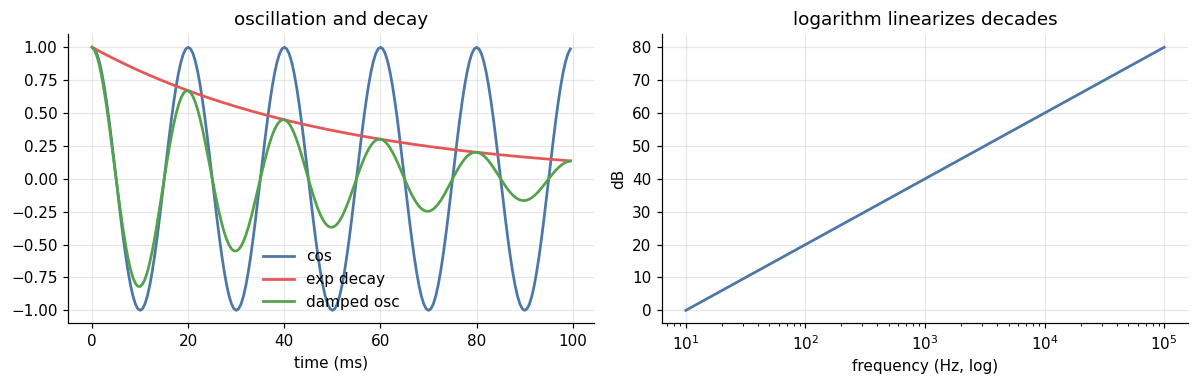

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(t*1e3, osc, label="cos"); ax[0].plot(t*1e3, decay, label="exp decay")
ax[0].plot(t*1e3, damped, label="damped osc")
ax[0].set_xlabel("time (ms)"); ax[0].set_title("oscillation and decay"); ax[0].legend()
ax[1].semilogx(decades, 20*np.log10(decades/decades[0]))
ax[1].set_xlabel("frequency (Hz, log)"); ax[1].set_ylabel("dB")
ax[1].set_title("logarithm linearizes decades")
plt.tight_layout(); plt.show()

## PyTorch (optional)

In [7]:
if torch is not None:
    tt = torch.tensor(t)
    d = torch.exp(-tt/tau) * torch.cos(2*np.pi*f0*tt)
    print("torch damped max:", float(d.max()), "| numpy:", float(damped.max()))
else:
    print("PyTorch absent -- NumPy waveforms above are authoritative.")

PyTorch absent -- NumPy waveforms above are authoritative.


## Exercises

1. Derive the sum-to-product identity $\cos\alpha+\cos\beta=2\cos\frac{\alpha+\beta}{2}
   \cos\frac{\alpha-\beta}{2}$ and use it to explain acoustic beats.
2. Fit $a\cos\omega t+b\sin\omega t$ to a noisy sampled sinusoid by least squares and recover
   $A,\phi$.
3. Show that a signal decaying as $e^{-t/\tau}$ falls by $8.69\,\mathrm{dB}$ per time constant.

## Engineering applications

A **direct-digital synthesizer** builds a sinusoid by incrementing a phase accumulator and
reading a cosine lookup table -- the discrete form of $\cos(\omega t)$, with $\omega$ set by the
increment. **Firmware** stores the table; a **DSP** demodulator projects a signal onto $\cos\omega t$
and $\sin\omega t$ (the $a,b$ above) to recover amplitude and phase. Logarithmic axes let a single
plot span the decades of frequency an instrument covers.

Summary (subject-verb-object): the accumulator advances the phase; the table yields the sinusoid; the
demodulator projects onto sine and cosine; the log scale compresses the decades.